This is a simple notebook to assist with quick visualization of the indices dataset.

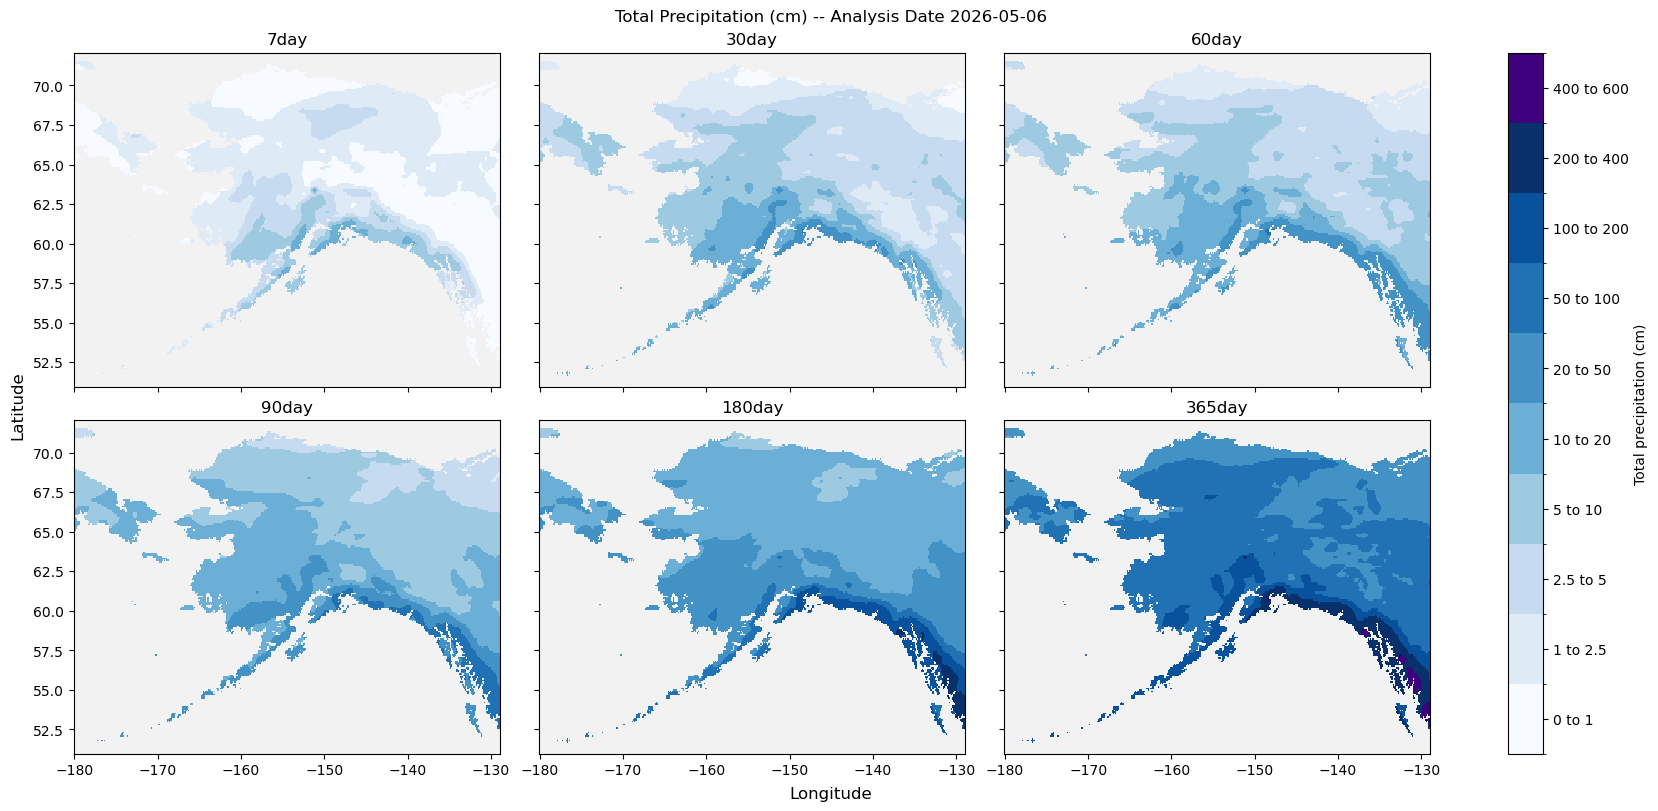

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import BoundaryNorm, ListedColormap

data_dir = Path("snap/drought_outputs")

all_files = [
    Path("snap/drought_outputs/drought_indices_1day.nc"),
    Path("snap/drought_outputs/drought_indices_7day.nc"),
    Path("snap/drought_outputs/drought_indices_30day.nc"),
    Path("snap/drought_outputs/drought_indices_60day.nc"),
    Path("snap/drought_outputs/drought_indices_90day.nc"),
    Path("snap/drought_outputs/drought_indices_180day.nc"),
    Path("snap/drought_outputs/drought_indices_365day.nc"),
]

variable_key = "tp"
long_name = "Total Precipitation (cm)"
analysis_date = "2026-05-06"

# Discrete total precipitation categories in cm.
#
# These bins are intentionally non-uniform because the accumulation windows
# span very different ranges, from ~20 cm for 7-day totals to >500 cm for
# 365-day totals.
bounds = [0, 1, 2.5, 5, 10, 20, 50, 100, 200, 400, 600]

colors = [
    "#f7fbff",  # 0 to 1 cm
    "#deebf7",  # 1 to 2.5 cm
    "#c6dbef",  # 2.5 to 5 cm
    "#9ecae1",  # 5 to 10 cm
    "#6baed6",  # 10 to 20 cm
    "#4292c6",  # 20 to 50 cm
    "#2171b5",  # 50 to 100 cm
    "#08519c",  # 100 to 200 cm
    "#08306b",  # 200 to 400 cm
    "#3f007d",  # 400 to 600 cm
]

cmap = ListedColormap(colors)
cmap.set_bad("#f2f2f2")  # missing / masked cells

norm = BoundaryNorm(bounds, cmap.N, clip=True)

cbar_labels = [
    "0 to 1",
    "1 to 2.5",
    "2.5 to 5",
    "5 to 10",
    "10 to 20",
    "20 to 50",
    "50 to 100",
    "100 to 200",
    "200 to 400",
    "400 to 600",
]

# Put colorbar ticks at bin centers.
cbar_ticks = [
    0.5,
    1.75,
    3.75,
    7.5,
    15,
    35,
    75,
    150,
    300,
    500,
]

short_window_files = [all_files[0]]
long_window_files = all_files[1::]


def open_nc(path: str | Path) -> xr.Dataset:
    """Open a NetCDF file with decoding enabled."""
    return xr.open_dataset(path)


def plot_variable_across_files(
    paths: list[str | Path],
    figsize_per_panel: tuple[float, float] = (5.5, 4.0),
    save_path: str | Path | None = None,
) -> plt.Figure:
    """Compare total precipitation across multiple NetCDF files."""

    ncols = 3
    nrows = 2

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True,
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    opened: list[tuple[Path, xr.Dataset]] = []

    for path in paths:
        p = Path(path)
        ds = open_nc(p)
        opened.append((p, ds))

    mesh = None

    for ax, (path, ds) in zip(axes.flat, opened, strict=False):
        #da = ds[variable_key]
        da = ds[variable_key].where(ds["smd"].notnull())
        lon = ds["longitude"].values
        lat = ds["latitude"].values

        mesh = ax.pcolormesh(
            lon,
            lat,
            da.values,
            shading="auto",
            cmap=cmap,
            norm=norm,
        )

        ax.set_title(Path(path).stem.split("_")[-1])
        ax.label_outer()

    if mesh is None:
        raise ValueError("No input files were provided.")

    fig.supxlabel("Longitude")
    fig.supylabel("Latitude")

    cbar = fig.colorbar(
        mesh,
        ax=axes.ravel().tolist(),
        boundaries=bounds,
        ticks=cbar_ticks,
        spacing="uniform",
    )

    cbar.set_ticklabels(cbar_labels)
    cbar.set_label("Total precipitation (cm)")

    fig.suptitle(
        f"{long_name} -- Analysis Date {analysis_date}",
        fontsize=12,
    )

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")


plot_variable_across_files(long_window_files, save_path="tp.png")